# Battery Data Exploratory Data Analysis (EDA)

This notebook contains visualization logic for analyzing MIT-Stanford and HUST LFP battery datasets, focusing on degradation trends and protocol efficacy.

## 1. Setup and Imports

In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from tqdm.auto import tqdm
import matplotlib.ticker as ticker
from src.data.loaders import load_mit, load_hust, MITCell, HUSTCell

%matplotlib inline
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

## 2. Load Data

In [ ]:
print("Loading MIT dataset...")
mit_cells = load_mit()
print(f"Loaded {len(mit_cells)} MIT cells.")

print("Loading HUST dataset...")
hust_cells = load_hust()
print(f"Loaded {len(hust_cells)} HUST cells.")

## 3. MIT Batch Analysis (V2)

Analyzes charging policies, cycle life, and service time for the MIT dataset.

In [ ]:
def run_mit_batch_analysis_v2(mit_cells):
    data_list = []
    for cid, cell in tqdm(mit_cells.items(), desc="Processing MIT Metrics"):
        load = cell.get_charge_load()
        if cell.cycle_life is None or load <= 0:
            continue
        c1_match = re.search(r"(\d+\.?\d*)C", cell.charge_policy)
        c1 = float(c1_match.group(1)) if c1_match else 0.0
        try:
            cyc1 = str(sorted([int(k) for k in cell.cycles.keys() if int(k) > 0])[0])
            data1 = cell.cycles[cyc1]
            t_sec = cell._get_time_in_seconds(data1["t"])
            dis_mask = data1["I"] < -0.1
            data_list.append({
                "Cell ID": cid, "Policy": cell.charge_policy, "C1": c1,
                "Charge Load (C-%)": load, "Cycle Life": cell.cycle_life,
                "Avg Discharge Duration (min)": (t_sec[dis_mask].max() - t_sec[dis_mask].min()) / 60.0 if np.any(dis_mask) else 0.0
            })
        except: continue
    df = pd.DataFrame(data_list)
    plt.figure(figsize=(12, 6))
    sns.scatterplot(data=df, x="Charge Load (C-%)", y="Cycle Life", hue="C1", palette="viridis", s=100, alpha=0.7)
    plt.title("MIT Dataset: Charge Load vs. Cycle Life", fontsize=14, fontweight="bold")
    plt.grid(True, alpha=0.3)
    plt.show()
    return df

mit_df = run_mit_batch_analysis_v2(mit_cells)

## 4. HUST Throughput Analysis (Effective C-rate)

In [ ]:
def run_hust_throughput_analysis(hust_cells):
    data_list = []
    for cid, cell in tqdm(hust_cells.items(), desc="Processing HUST Metrics"):
        eff_c = cell.get_effective_c_rate()
        data_list.append({"Cell ID": cid, "Effective C-rate": eff_c, "Cycle Life": cell.cycle_life, "Batch": cell.batch_id})
    df = pd.DataFrame(data_list)
    plt.figure(figsize=(12, 6))
    sns.scatterplot(data=df, x="Effective C-rate", y="Cycle Life", hue="Batch", s=100, alpha=0.7)
    plt.title("HUST Dataset: Effective C-rate vs. Cycle Life", fontsize=14, fontweight="bold")
    plt.grid(True, alpha=0.3)
    plt.show()
    return df

hust_df = run_hust_throughput_analysis(hust_cells)

## 5. HUST Throughput Analysis (RMS C-rate)

In [ ]:
def run_hust_rms_analysis(hust_cells):
    data_list = []
    for cid, cell in tqdm(hust_cells.items()):
        stats = cell.get_cycle_stats(cycle_num=1)
        data_list.append({"Cell ID": cid, "RMS C-rate": stats.get("c_rate", 0.0), "Cycle Life": cell.cycle_life, "Batch": cell.batch_id})
    df = pd.DataFrame(data_list)
    plt.figure(figsize=(12, 6))
    sns.scatterplot(data=df, x="RMS C-rate", y="Cycle Life", hue="Batch", s=100, alpha=0.7)
    plt.title("HUST Dataset: RMS C-rate vs. Cycle Life")
    plt.show()

run_hust_rms_analysis(hust_cells)

## 6. HUST Degradation Milestones

In [ ]:
def plot_hust_milestones(hust_cells):
    data_list = [{"Cell ID": cid, "Life": cell.cycle_life, "Batch": cell.batch_id} for cid, cell in hust_cells.items()]
    df = pd.DataFrame(data_list)
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x="Life", hue="Batch", multiple="stack", bins=20)
    plt.title("Distribution of Cycle Life (HUST)")
    plt.show()

plot_hust_milestones(hust_cells)

## 7. HUST Protocol Efficacy Map

In [ ]:
def plot_hust_protocol_efficacy(hust_cells):
    data = []
    for cid, cell in hust_cells.items():
        stats = cell.get_cycle_stats(1)
        data.append({"D0": stats.get("D0_c_rate", 0), "D1": stats.get("D1_c_rate", 0), "Life": cell.cycle_life})
    df = pd.DataFrame(data)
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.pivot_table(index="D0", columns="D1", values="Life", aggfunc="mean"), cmap="RdYlGn")
    plt.title("Protocol Efficacy Map (HUST: D0 vs D1)")
    plt.show()

plot_hust_protocol_efficacy(hust_cells)

## 8. Refined Intensity vs. Life Analysis

In [ ]:
def plot_hust_intensity_refined(hust_cells):
    data = []
    for cid, cell in hust_cells.items():
        s = cell.get_cycle_stats(1)
        data.append({"Intensity": (s.get("D0_c_rate", 0) + s.get("D1_c_rate", 0))/2, "Life": cell.cycle_life})
    df = pd.DataFrame(data)
    plt.figure(figsize=(10, 6))
    sns.regplot(data=df, x="Intensity", y="Life")
    plt.title("Discharge Intensity vs. Cycle Life")
    plt.show()

plot_hust_intensity_refined(hust_cells)

## 9. Export Shortest and Longest Cycle Data (HUST)

In [ ]:
def export_hust_extremes(hust_cells):
    cids = sorted(hust_cells.keys(), key=lambda x: hust_cells[x].cycle_life)
    print(f"Shortest: {cids[0]} ({hust_cells[cids[0]].cycle_life}), Longest: {cids[-1]} ({hust_cells[cids[-1]].cycle_life})")

export_hust_extremes(hust_cells)

## 10. HUST D3 Duration Reduction Analysis

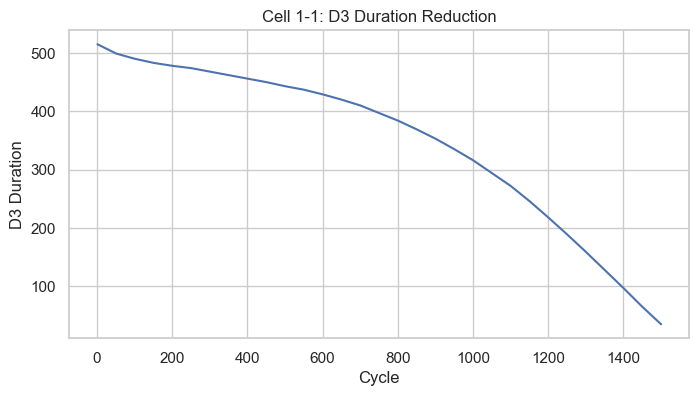

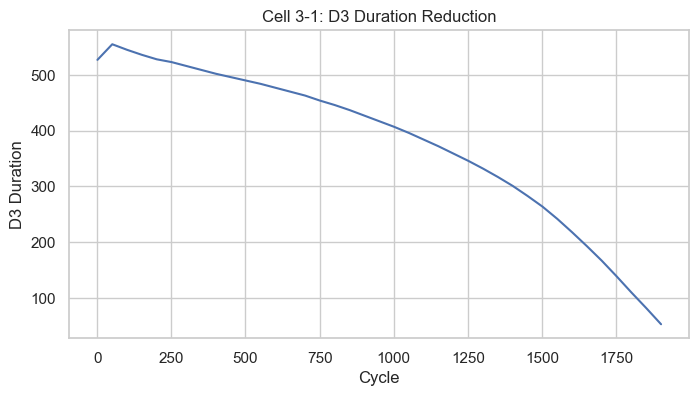

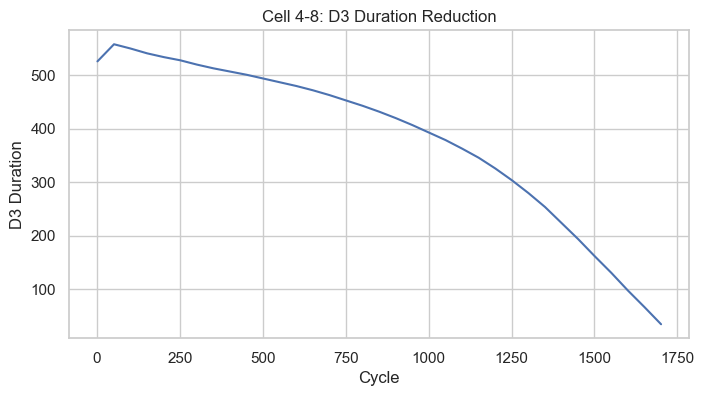

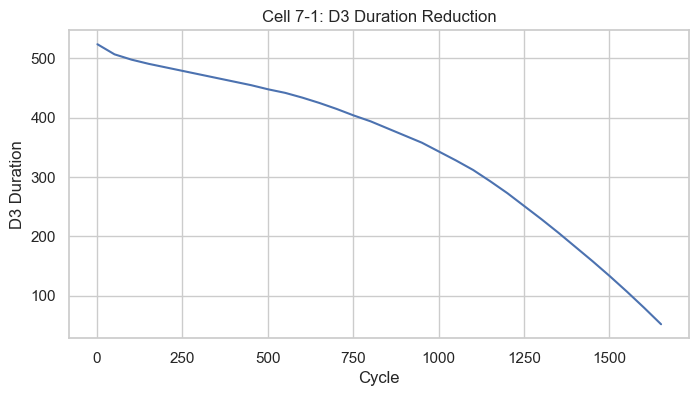

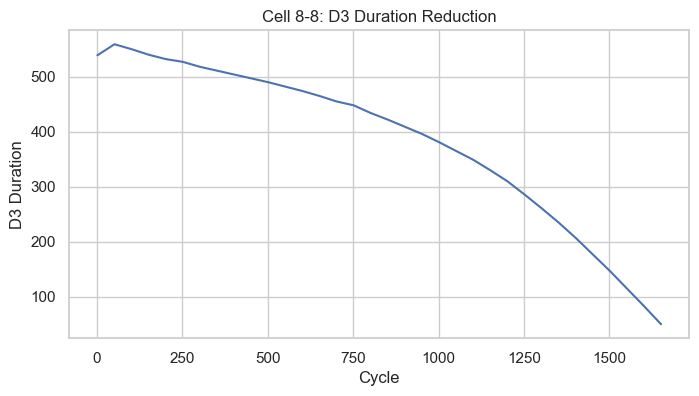

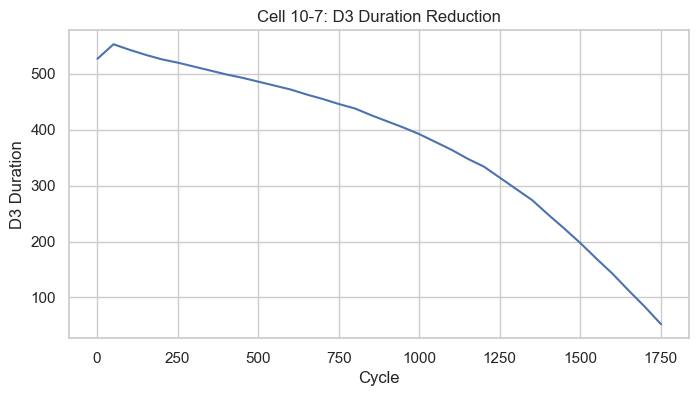

In [28]:
def plot_hust_d3_reduction(hust_cells, sample_size=5):
    cids = sorted(hust_cells.keys(), key=lambda x: [int(i) for i in x.split("-")])
    sample_cids = cids[::max(1, len(cids)//sample_size)]
    for cid in sample_cids:
        cell = hust_cells[cid]
        durations = []
        cycs = sorted(cell.data.keys())
        for cyc in cycs[::50]:
            stats = cell.get_cycle_stats(cyc)
            durations.append({"Cycle": cyc, "D3 Duration": stats.get("D3_duration", 0)})
        df = pd.DataFrame(durations)
        if not df.empty:
            plt.figure(figsize=(8, 4))
            sns.lineplot(data=df, x="Cycle", y="D3 Duration")
            plt.title(f"Cell {cid}: D3 Duration Reduction")
            plt.show()

plot_hust_d3_reduction(hust_cells)

## 11. HUST Stage Capacity Analysis (D0-D3)

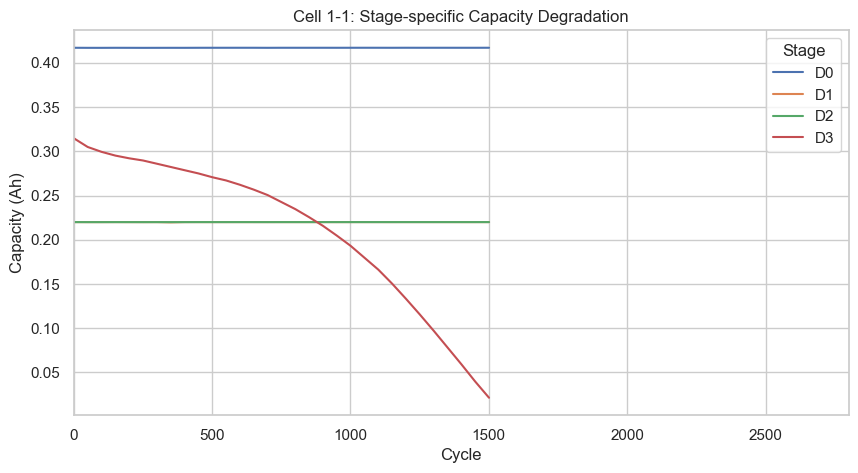

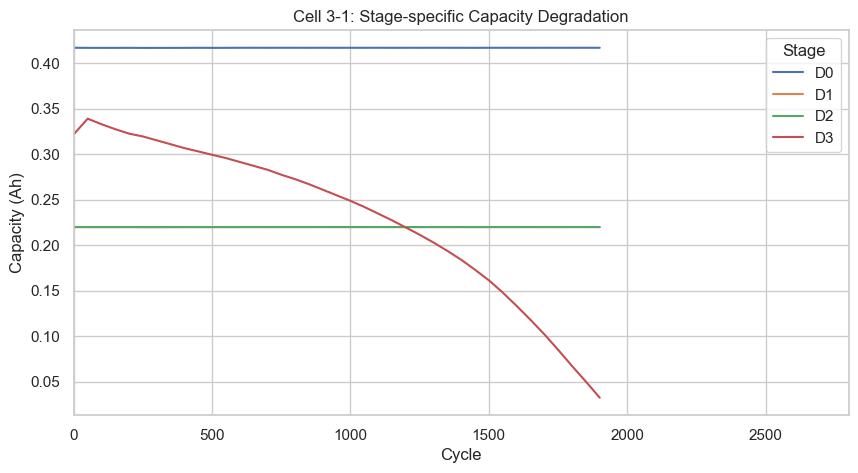

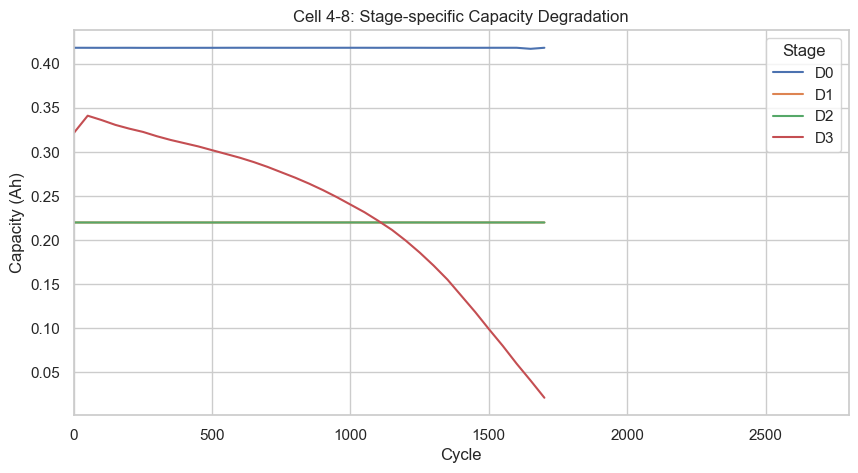

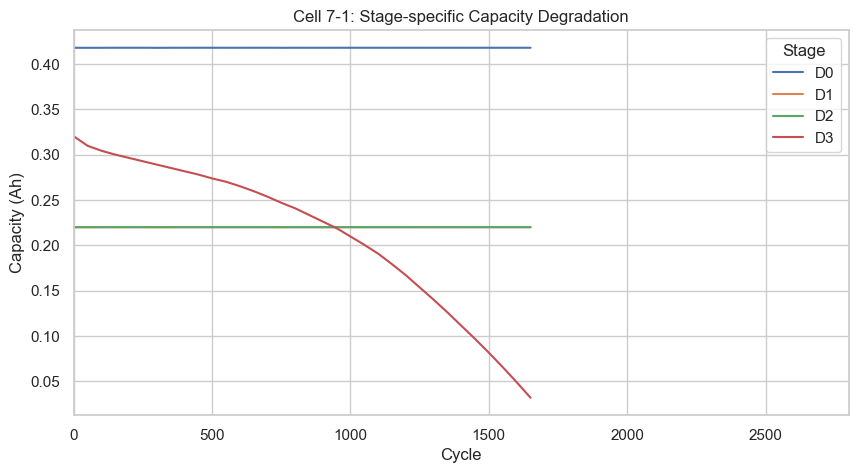

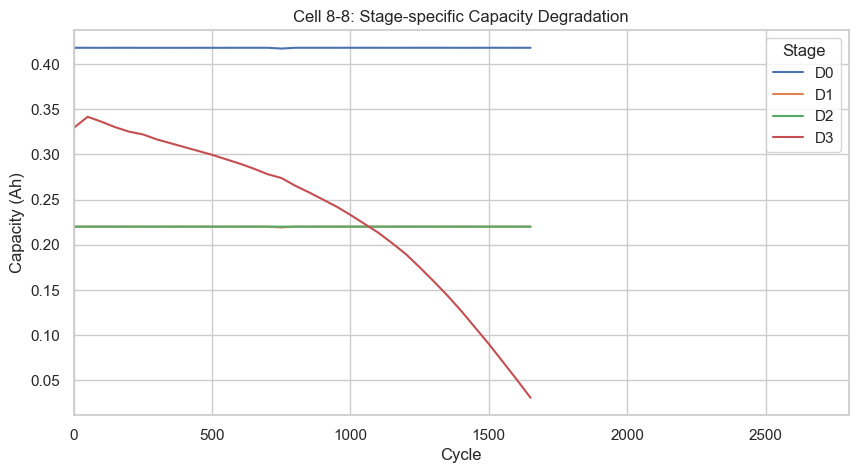

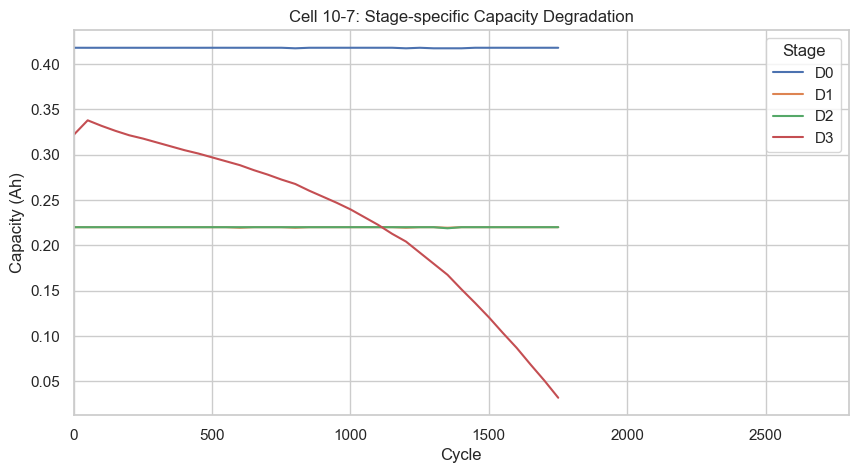

In [ ]:
def plot_hust_stage_capacities(hust_cells, sample_size=5):
    cids = sorted(hust_cells.keys(), key=lambda x: [int(i) for i in x.split("-")])
    sample_cids = cids[::max(1, len(cids)//sample_size)]
    for cid in sample_cids:
        cell = hust_cells[cid]
        data_list = []
        total_cycles = []
        total_capacities = []
        for cyc in sorted(cell.data.keys())[::50]:
            df = cell.data[cyc]
            col_s = [c for c in df.columns if "Status" in c][0]
            col_i = [c for c in df.columns if "Current" in c][0]
            col_t = [c for c in df.columns if "Time" in c][0]
            cycle_total_cap = 0
            for i in range(4):
                st_df = df[df[col_s].str.contains(f"discharge_{i}", case=False, na=False)]
                if not st_df.empty:
                    t = st_df[col_t].values
                    cap = np.sum(np.abs(st_df[col_i].values) * np.diff(t, prepend=t[0])) / 3600000.0
                    data_list.append({"Cycle": cyc, "Stage": f"D{i}", "Capacity (Ah)": cap})
                    cycle_total_cap += cap
            if cycle_total_cap > 0:
                total_cycles.append(cyc)
                total_capacities.append(cycle_total_cap)
        if data_list:
            plt.figure(figsize=(10, 5))
            sns.lineplot(data=pd.DataFrame(data_list), x="Cycle", y="Capacity (Ah)", hue="Stage")
            plt.plot(total_cycles, total_capacities, color="black", linestyle="--", label="Total Discharge")
            plt.title(f"Cell {cid}: Stage-specific Capacity Degradation")
            plt.xlim(0, 2800)
            plt.legend()
            plt.savefig(f"./outputs/figures/eda/hust/hust_cell_{cid}_stage_capacities.png", dpi=300, bbox_inches="tight")  
            plt.show()

plot_hust_stage_capacities(hust_cells)

## 12. HUST 3D Degradation Path Analysis (D3)

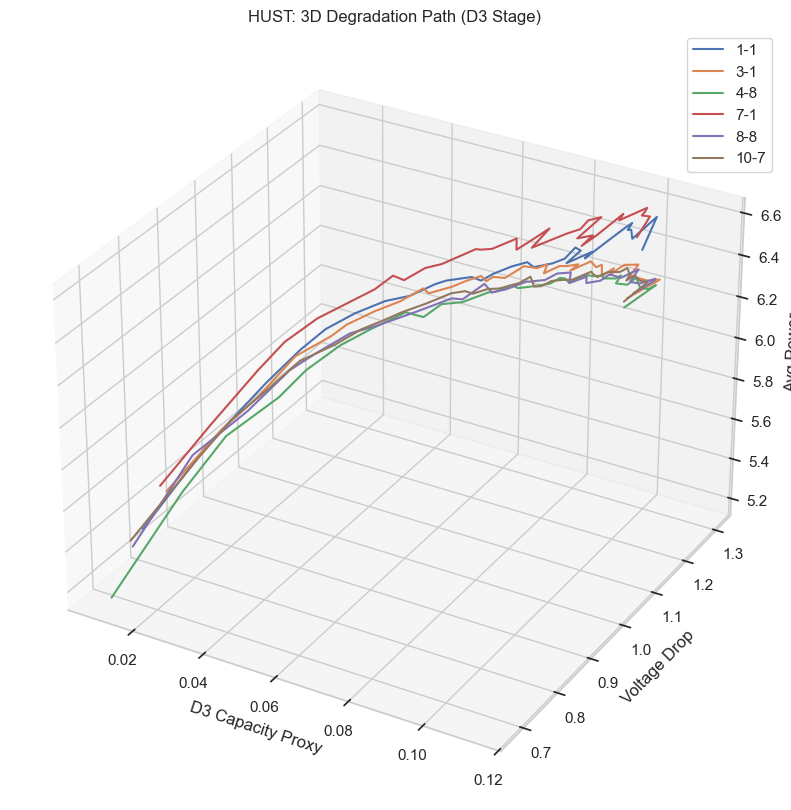

In [31]:
def plot_hust_3d_degradation(hust_cells, sample_size=5):
    from mpl_toolkits.mplot3d import Axes3D
    cids = sorted(hust_cells.keys(), key=lambda x: [int(i) for i in x.split("-")])
    sample_cids = cids[::max(1, len(cids)//sample_size)]
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    for cid in sample_cids:
        cell = hust_cells[cid]
        caps, v_drops, powers = [], [], []
        for cyc in sorted(cell.data.keys())[::50]:
            df = cell.data[cyc]
            col_s = [c for c in df.columns if "Status" in c][0]
            col_v = [c for c in df.columns if "Voltage" in c][0]
            col_i = [c for c in df.columns if "Current" in c][0]
            st_df = df[df[col_s].str.contains("discharge_3", case=False, na=False)]
            if not st_df.empty:
                caps.append(len(st_df)*0.001)
                v_drops.append(st_df[col_v].iloc[0] - st_df[col_v].iloc[-1])
                powers.append(np.mean(st_df[col_v] * np.abs(st_df[col_i]) / 1000.0))
        ax.plot(caps, v_drops, powers, label=cid)
    ax.set_xlabel("D3 Capacity Proxy"); ax.set_ylabel("Voltage Drop"); ax.set_zlabel("Avg Power")
    plt.title("HUST: 3D Degradation Path (D3 Stage)")
    plt.legend()
    plt.show()

plot_hust_3d_degradation(hust_cells)

## 13. HUST 2D Degradation Path with Power Colormap

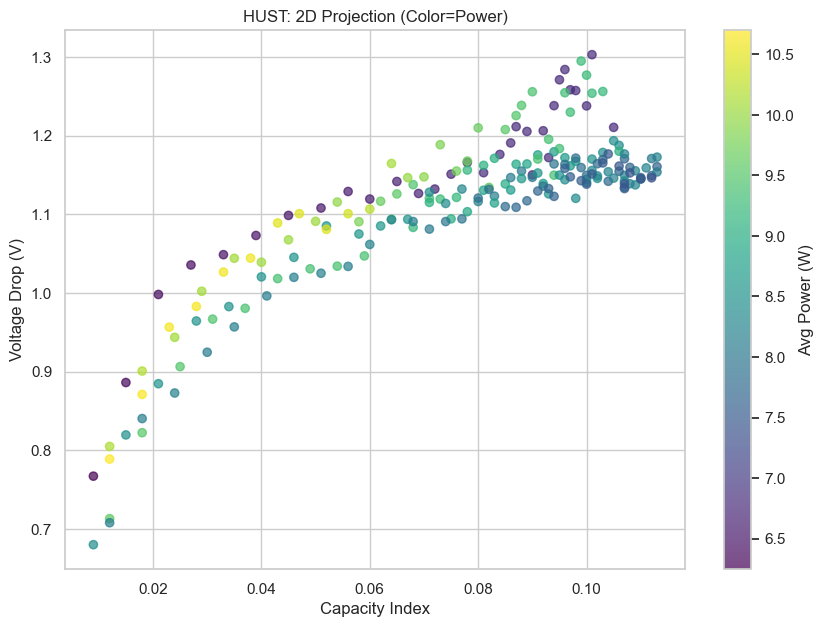

In [38]:
def plot_hust_2d_power_colormap(hust_cells, sample_size=5):
    cids = sorted(hust_cells.keys(), key=lambda x: [int(i) for i in x.split("-")])
    sample_cids = cids[::max(1, len(cids)//sample_size)]
    all_caps, all_v_drops, all_powers = [], [], []
    for cid in sample_cids:
        cell = hust_cells[cid]
        for cyc in sorted(cell.data.keys())[::50]:
            df = cell.data[cyc]
            col_s = [c for c in df.columns if "Status" in c][0]
            col_v = [c for c in df.columns if "Voltage" in c][0]
            col_i = [c for c in df.columns if "Current" in c][0]
            st_df = df[df[col_s].str.contains("discharge_3", case=False, na=False)]
            if not st_df.empty:
                all_caps.append(len(st_df)*0.001)
                all_v_drops.append(st_df[col_v].iloc[0] - st_df[col_v].iloc[-1])
                # all_powers.append(np.mean(st_df[col_v] * np.abs(st_df[col_i]) / 1000.0))
                all_powers.append(np.mean(df[col_v] * np.abs(df[col_i]) / 1000.0))
    if all_caps:
        plt.figure(figsize=(10, 7))
        sc = plt.scatter(all_caps, all_v_drops, c=all_powers, cmap='viridis', alpha=0.7)
        plt.colorbar(sc, label="Avg Power (W)")
        plt.xlabel("Capacity Index"); plt.ylabel("Voltage Drop (V)")
        plt.title("HUST: 2D Projection (Color=Power)")
        plt.show()

plot_hust_2d_power_colormap(hust_cells)

## 14. HUST 3D Protocol Space: Integrated D3 Capacity Health Metric

Visualizes the cumulative health indicator (Integrated D3 Capacity up to cycle 1140).
Refined with integer ticks and space-crossing dashed grid lines.

Calculating D3 Integrals:   0%|          | 0/77 [00:00<?, ?it/s]

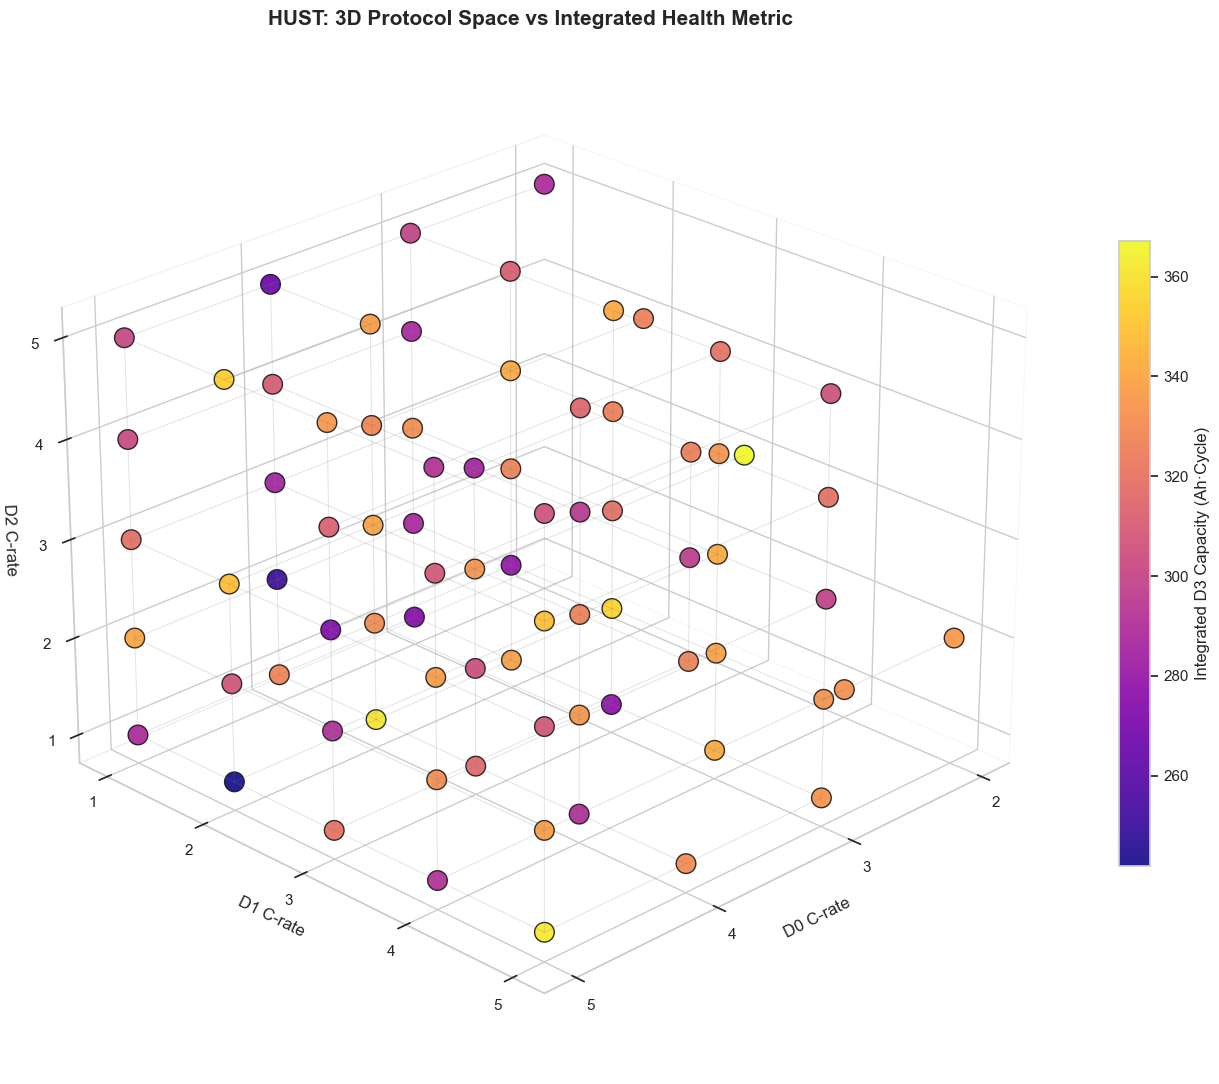

In [ ]:
def plot_hust_3d_protocol_integral_refined(hust_cells, sample_size=60):
    from mpl_toolkits.mplot3d import Axes3D
    import matplotlib.ticker as ticker
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from tqdm.auto import tqdm
    
    cids = sorted(hust_cells.keys(), key=lambda x: [int(i) for i in x.split("-")])
    sample_cids = cids[::max(1, len(cids)//sample_size)]
    cell_stats = []
    TARGET_CYCLE = 1140
    
    for cid in tqdm(sample_cids, desc="Calculating D3 Integrals"):
        cell = hust_cells[cid]
        cycs = sorted([c for c in cell.data.keys() if c <= TARGET_CYCLE])
        caps, valid_cycs = [], []
        for cyc in cycs:
            df = cell.data[cyc]
            col_s = [c for c in df.columns if "Status" in c][0]
            col_i = [c for c in df.columns if "Current" in c][0]
            col_t = [c for c in df.columns if "Time" in c][0]
            d3_df = df[df[col_s].str.contains("discharge_3", case=False, na=False)]
            if not d3_df.empty:
                t = d3_df[col_t].values
                d3_cap = np.sum(np.abs(d3_df[col_i].values) * np.diff(t, prepend=t[0])) / 3600000.0
                caps.append(d3_cap)
                valid_cycs.append(cyc)
        if len(caps) > 5:
            val = np.trapezoid(caps, valid_cycs) if hasattr(np, 'trapezoid') else np.trapz(caps, valid_cycs)
            p = cell.get_cycle_stats(valid_cycs[0])
            cell_stats.append({"D0": p.get("D0_c_rate", 0), "D1": p.get("D1_c_rate", 0), "D2": p.get("D2_c_rate", 0), "Integral": val})
    
    if not cell_stats: return
    df = pd.DataFrame(cell_stats)
    fig = plt.figure(figsize=(14, 11))
    ax = fig.add_subplot(111, projection='3d')
    
    # 각 축의 최댓값 계산 (진하기 비율 계산용, 0으로 나누기 방지)
    max_d0 = max(df["D0"].max(), 0.1)
    max_d1 = max(df["D1"].max(), 0.1)
    max_d2 = max(df["D2"].max(), 0.1)
    
    ax.set_xticks(range(0, int(np.ceil(max_d0)) + 1))
    ax.set_yticks(range(0, int(np.ceil(max_d1)) + 1))
    ax.set_zticks(range(0, int(np.ceil(max_d2)) + 1))
    
    ax.grid(True, linestyle='--', linewidth=0.8, alpha=0.3, color='gray')
    ax.xaxis.pane.fill = ax.yaxis.pane.fill = ax.zaxis.pane.fill = False
    
    # 좌표 추출 및 인접 데이터 연결선 그리기 (RGB 매핑 및 법선 기반 진하기 조절)
    coords = df[["D0", "D1", "D2"]].drop_duplicates().values
    for i in range(len(coords)):
        for j in range(i + 1, len(coords)):
            p1, p2 = coords[i], coords[j]
            diff = np.abs(p1 - p2)
            dist = np.sum(diff)
            
            # 거리가 0.9 ~ 1.1 사이인 인접 노드만 연결
            if 0.9 <= dist <= 1.1:
                if diff[0] > 0.5: 
                    # D0 방향으로 변하는 선 (Red) -> 법선 D2 값에 따라 진해짐
                    intensity = 0.2 + 0.8 * (p1[2] / max_d2)
                    color = (1.0, 0.0, 0.0, intensity)
                elif diff[1] > 0.5: 
                    # D1 방향으로 변하는 선 (Green) -> 법선 D0 값에 따라 진해짐
                    intensity = 0.2 + 0.8 * (p1[0] / max_d0)
                    color = (0.0, 0.8, 0.0, intensity)
                elif diff[2] > 0.5: 
                    # D2 방향으로 변하는 선 (Blue) -> 법선 D1 값에 따라 진해짐
                    intensity = 0.2 + 0.8 * (p1[1] / max_d1)
                    color = (0.0, 0.4, 1.0, intensity)
                else:
                    color = (0.5, 0.5, 0.5, 0.5)
                
                # 색상 구분을 명확히 하기 위해 선 두께를 2.0으로 상향
                ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], color=color, linewidth=2.0)
    
    # 메인 Scatter 플롯
    sc = ax.scatter(df["D0"], df["D1"], df["D2"], c=df["Integral"], cmap="plasma", s=200, edgecolors='k', alpha=0.9, depthshade=True)
    plt.colorbar(sc, shrink=0.6, label="Integrated D3 Capacity (Ah·Cycle)")
    
    ax.set_xlabel("D0 C-rate"); ax.set_ylabel("D1 C-rate"); ax.set_zlabel("D2 C-rate")
    ax.set_title("HUST: 3D Protocol Space vs Integrated Health Metric\n(RGB Lines indicate plane directions & varying intensities)", fontsize=14, fontweight="bold")
    ax.view_init(elev=25, azim=45)
    plt.tight_layout()
    plt.show()

plot_hust_3d_protocol_integral_refined(hust_cells)

In [40]:
def plot_hust_3d_protocol_slope(hust_cells, sample_size=15):
    from mpl_toolkits.mplot3d import Axes3D
    
    cids = sorted(hust_cells.keys(), key=lambda x: [int(i) for i in x.split("-")])
    # sample_cids = cids[::max(1, len(cids)//sample_size)]
    sample_cids = cids
    
    all_data = []
    
    for cid in tqdm(sample_cids, desc="Calculating Slopes"):
        cell = hust_cells[cid]
        cycs = sorted(cell.data.keys())
        
        temp_list = []
        for cyc in cycs:
            stats = cell.get_cycle_stats(cycle_num=cyc)
            
            df = cell.data[cyc]
            col_s = [c for c in df.columns if "Status" in c][0]
            col_i = [c for c in df.columns if "Current" in c][0]
            col_t = [c for c in df.columns if "Time" in c][0]
            
            d3_df = df[df[col_s].str.contains("discharge_3", case=False, na=False)]
            if not d3_df.empty:
                i_ma = np.abs(d3_df[col_i].values)
                t = d3_df[col_t].values
                dt = np.diff(t, prepend=t[0])
                d3_cap = np.sum(i_ma * dt) / (3600.0 * 1000.0)
                
                temp_list.append({
                    "Cycle": cyc,
                    "D3_Cap": d3_cap,
                    "D0_rate": stats.get("D0_c_rate", 0.0),
                    "D1_rate": stats.get("D1_c_rate", 0.0),
                    "D2_rate": stats.get("D2_c_rate", 0.0)
                })
        
        if len(temp_list) > 1:
            df_temp = pd.DataFrame(temp_list)
            # Calculate gradient: d(Capacity) / d(Cycle)
            # We use negative of gradient to show 'rate of loss' as positive if preferred, 
            # but here we'll keep the raw slope (usually negative).
            df_temp["Slope"] = np.gradient(df_temp["D3_Cap"], df_temp["Cycle"])
            all_data.append(df_temp)
                
    if not all_data:
        return
        
    df_plot = pd.concat(all_data)
    
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Enable grid and customize appearance
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    
    # Use every 10th point for the plot to avoid over-crowding if necessary, 
    # but here we use all calculated slopes for the sampled cells.
    sc = ax.scatter(
        df_plot["D0_rate"], 
        df_plot["D1_rate"], 
        df_plot["D2_rate"], 
        c=df_plot["Slope"], 
        cmap="RdYlGn", # Red for high loss (steep negative slope), Green for stability
        s=40, 
        alpha=0.7,
        edgecolors='w', 
        linewidth=0.3
    )
    
    cbar = plt.colorbar(sc, pad=0.1)
    cbar.set_label("D3 Capacity Slope (Ah/Cycle)", fontsize=12)
    
    ax.set_xlabel("D0 C-rate", fontsize=11)
    ax.set_ylabel("D1 C-rate", fontsize=11)
    ax.set_zlabel("D2 C-rate", fontsize=11)
    ax.set_title("HUST: Protocol Space vs. D3 Capacity Degradation Rate", fontsize=15, fontweight="bold")
    
    # Adjust view for better perspective
    ax.view_init(elev=25, azim=45)
    
    plt.tight_layout()
    plt.show()

plot_hust_3d_protocol_slope(hust_cells)

Calculating Slopes:   0%|          | 0/77 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 15. 2D Projections of Protocol Space (Integrated Health Metric)

Handles overlaps by calculating the mean integral value for each protocol coordinate.

In [ ]:
def plot_hust_2d_projections(hust_cells, sample_size=60):
    import matplotlib.ticker as ticker
    cids = sorted(hust_cells.keys(), key=lambda x: [int(i) for i in x.split("-")])
    cell_stats = []
    TARGET_CYCLE = 1140
    for cid in tqdm(cids, desc="Processing"):
        cell = hust_cells[cid]
        cycs = sorted([c for c in cell.data.keys() if c <= TARGET_CYCLE])
        caps, v_cycs = [], []
        for cyc in cycs:
            df = cell.data[cyc]
            col_s = [c for c in df.columns if "Status" in c][0]
            col_i = [c for c in df.columns if "Current" in c][0]
            col_t = [c for c in df.columns if "Time" in c][0]
            d3_df = df[df[col_s].str.contains("discharge_3", case=False, na=False)]
            if not d3_df.empty:
                t = d3_df[col_t].values
                caps.append(np.sum(np.abs(d3_df[col_i].values) * np.diff(t, prepend=t[0])) / 3600000.0)
                v_cycs.append(cyc)
        if len(caps) > 5:
            val = np.trapezoid(caps, v_cycs) if hasattr(np, 'trapezoid') else np.trapz(caps, v_cycs)
            p = cell.get_cycle_stats(v_cycs[0])
            cell_stats.append({"D0": p.get("D0_c_rate", 0), "D1": p.get("D1_c_rate", 0), "D2": p.get("D2_c_rate", 0), "Integral": val})
    
    if not cell_stats: return
    df_raw = pd.DataFrame(cell_stats)
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    projs = [("D0", "D1"), ("D1", "D2"), ("D0", "D2")]
    for i, (xc, yc) in enumerate(projs):
        df_p = df_raw.groupby([xc, yc])["Integral"].mean().reset_index()
        sc = axes[i].scatter(df_p[xc], df_p[yc], c=df_p["Integral"], cmap="plasma", s=150, alpha=0.9, edgecolors='k')
        axes[i].set_xlabel(f"{xc} C-rate"); axes[i].set_ylabel(f"{yc} C-rate")
        axes[i].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        axes[i].yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        axes[i].grid(True, linestyle=':', alpha=0.6)
    plt.colorbar(sc, ax=axes.ravel().tolist(), label="Mean Integrated Health")
    plt.show()

plot_hust_2d_projections(hust_cells)

## 16. Protocol Efficacy Analysis: Stage-Specific Capacity vs. Lifetime Service

This plot analyzes how the capacity delivered in the D3 stage (the final discharge stage in the HUST protocol) correlates with the total service time, colored by initial total capacity and sized by total energy throughput.

Calculating 3 Metrics:   0%|          | 0/77 [00:00<?, ?it/s]

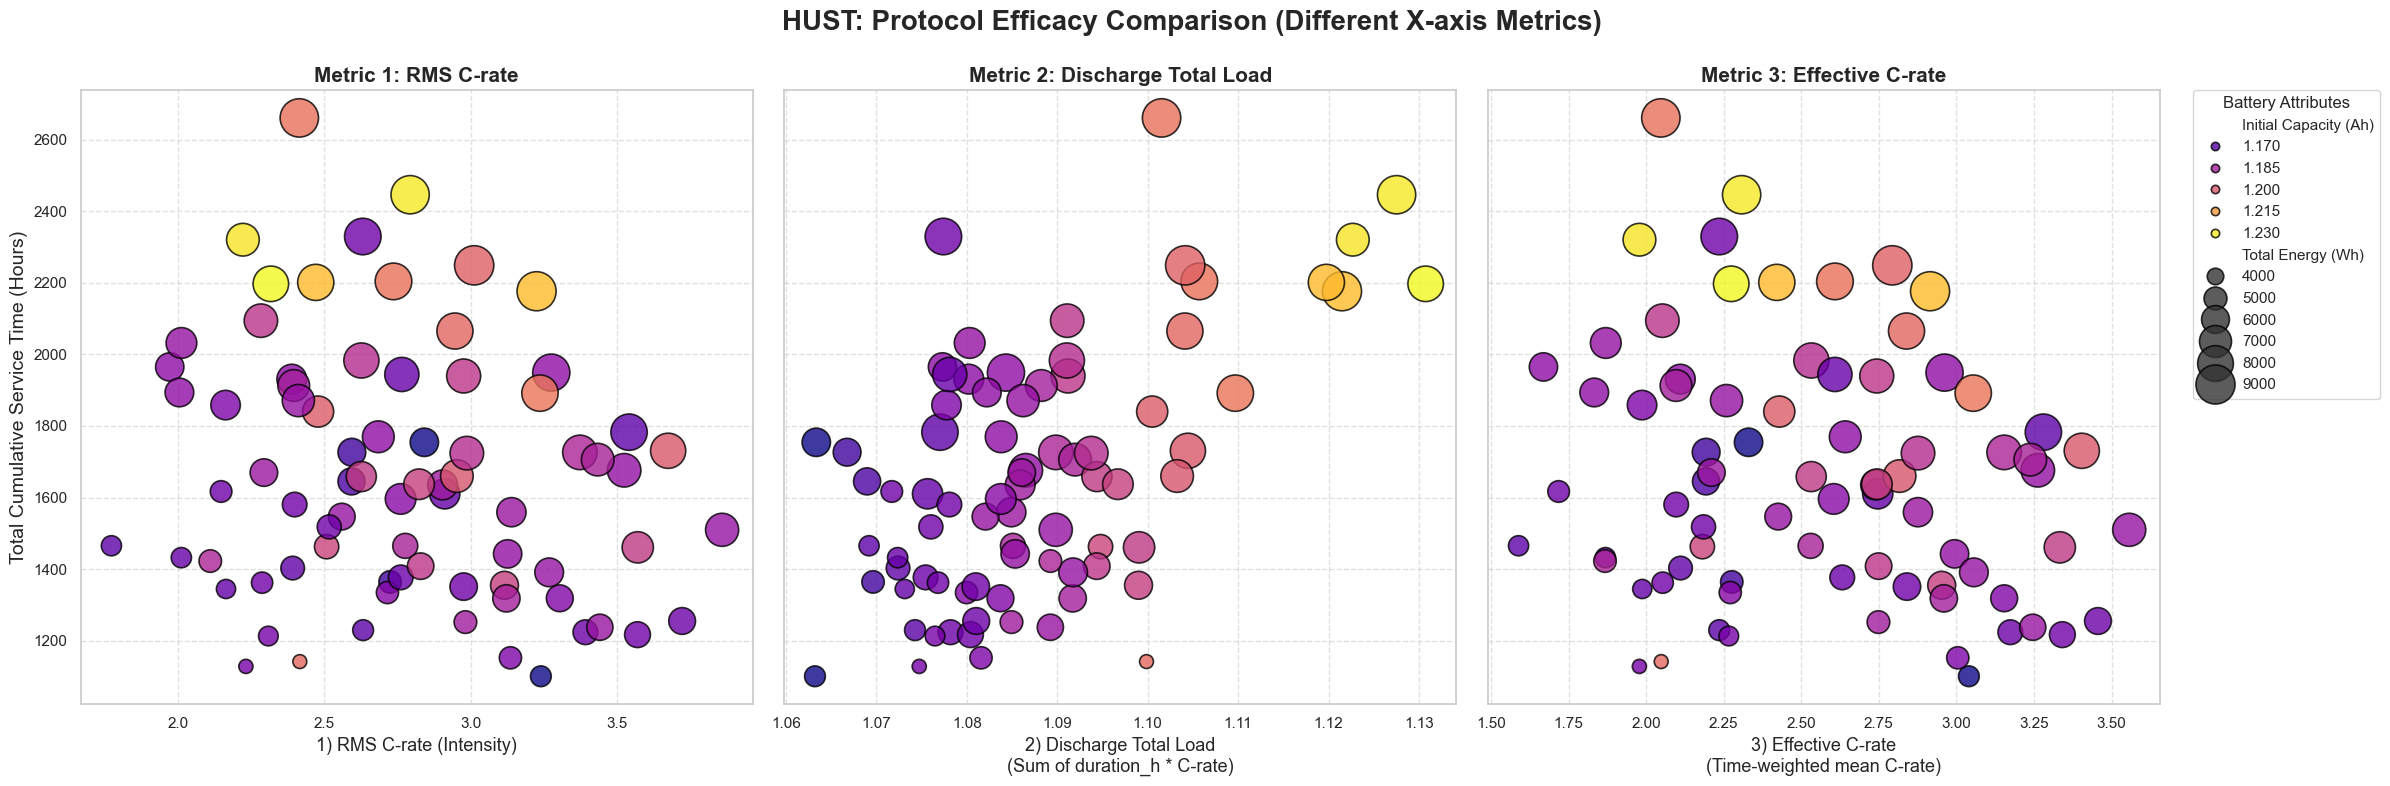

In [45]:
def plot_hust_protocol_efficacy_v3_comparison(hust_cells):
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from tqdm.auto import tqdm

    sns.set_theme(style="whitegrid")
    data_list = []
    
    for cid, cell in tqdm(hust_cells.items(), desc="Calculating 3 Metrics"):
        try:
            cyc_keys = sorted(cell.data.keys())
            cyc1 = cyc_keys[0]
            df1 = cell.data[cyc1]
            
            col_i = [c for c in df1.columns if "Current" in c][0]
            col_t = [c for c in df1.columns if "Time" in c][0]
            
            # 1. 방전 구간 필터링 (전류가 음수인 구간, 노이즈 제외)
            dis_df = df1[df1[col_i] <= -10]
            if dis_df.empty: continue
                
            t = dis_df[col_t].values
            i_ma = np.abs(dis_df[col_i].values) # 단위: mA
            dt_sec = np.diff(t, prepend=t[0])
            dt_hours = dt_sec / 3600.0
            
            # 순간 C-rate 배열 (A123 18650 셀 정격 용량 1100mAh 기준)
            c_rate_array = i_ma / 1100.0
            
            # ===== 3가지 X축 지표 계산 =====
            # 1) RMS C-rate (제곱평균제곱근 방전율)
            rms_c_rate = np.sqrt(np.sum((c_rate_array**2) * dt_sec) / np.sum(dt_sec))
            
            # 2) Discharge Total Load (Sum of duration * C-rate)
            # duration을 시간(h) 단위로 곱하여 실질적 누적 부하량(Ah equivalent) 산출
            discharge_total_load = np.sum(c_rate_array * dt_hours)
            
            # 3) Effective C-rate (Time-weighted mean of C-rate)
            effective_c_rate = np.sum(c_rate_array * dt_sec) / np.sum(dt_sec)
            
            # ===== Y축 및 부가 지표 =====
            total_service_time_s = sum(df[col_t].max() - df[col_t].min() for df in cell.data.values())
            initial_cap_ah = cell.dq[cyc1] / 1000.0
            total_energy_wh = cell.get_throughput_wh()
            
            data_list.append({
                "Cell ID": cid,
                "RMS C-rate": rms_c_rate,
                "Discharge Total Load": discharge_total_load,
                "Effective C-rate": effective_c_rate,
                "Total Service Time (h)": total_service_time_s / 3600.0,
                "Initial Capacity (Ah)": initial_cap_ah,
                "Total Energy (Wh)": total_energy_wh
            })
        except:
            continue
            
    if not data_list: return
    df = pd.DataFrame(data_list)
    
    # 1행 3열의 서브플롯 생성
    fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharey=True)
    fig.suptitle("HUST: Protocol Efficacy Comparison (Different X-axis Metrics)", fontsize=20, fontweight="bold")
    
    x_metrics = ["RMS C-rate", "Discharge Total Load", "Effective C-rate"]
    x_labels = [
        "1) RMS C-rate (Intensity)", 
        "2) Discharge Total Load\n(Sum of duration_h * C-rate)", 
        "3) Effective C-rate\n(Time-weighted mean C-rate)"
    ]
    
    for i, (metric, label) in enumerate(zip(x_metrics, x_labels)):
        sns.scatterplot(
            data=df,
            x=metric,
            y="Total Service Time (h)",
            hue="Initial Capacity (Ah)",
            size="Total Energy (Wh)",
            sizes=(100, 800),
            palette="plasma",
            alpha=0.8,
            edgecolors="black",
            linewidth=1.2,
            ax=axes[i],
            legend=(i == 2) # 마지막 플롯에만 범례 표시
        )
        
        axes[i].set_title(f"Metric {i+1}: {metric}", fontsize=15, fontweight="bold")
        axes[i].set_xlabel(label, fontsize=13)
        axes[i].grid(True, linestyle='--', alpha=0.6)
        
        if i == 0:
            axes[i].set_ylabel("Total Cumulative Service Time (Hours)", fontsize=14)
        else:
            axes[i].set_ylabel("") # Y축을 공유하므로 2, 3번째 라벨은 생략
            
    # 범례 위치를 전체 그림의 오른쪽 바깥으로 빼기
    if axes[2].get_legend() is not None:
        axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Battery Attributes")
        
    plt.tight_layout()
    plt.subplots_adjust(top=0.88) # suptitle을 위한 공간 확보
    plt.show()

plot_hust_protocol_efficacy_v3_comparison(hust_cells)